# Color Scheme Reference for Thesis Visualizations

This notebook uses your GeoDataViz style as the primary scheme and keeps additional palettes as alternatives.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make project src importable from notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from energy_trading.visualization.style import apply_geo_style, ROLE_COLORS, GEO_DIVERGING, GEO_SEQUENTIAL_BLUE

sns.set_theme(style='whitegrid', context='talk')
apply_geo_style()

## 1) Primary Palette (GeoDataViz)

This section validates your central project style (`apply_geo_style`) and role-based colors.
Run this first and use it as the default in thesis plots.

figure.figsize: [12.0, 6.0]
axes.grid: True
grid.color: #EEEEEE
grid.linestyle: --
axes.spines.top: False
axes.spines.right: False


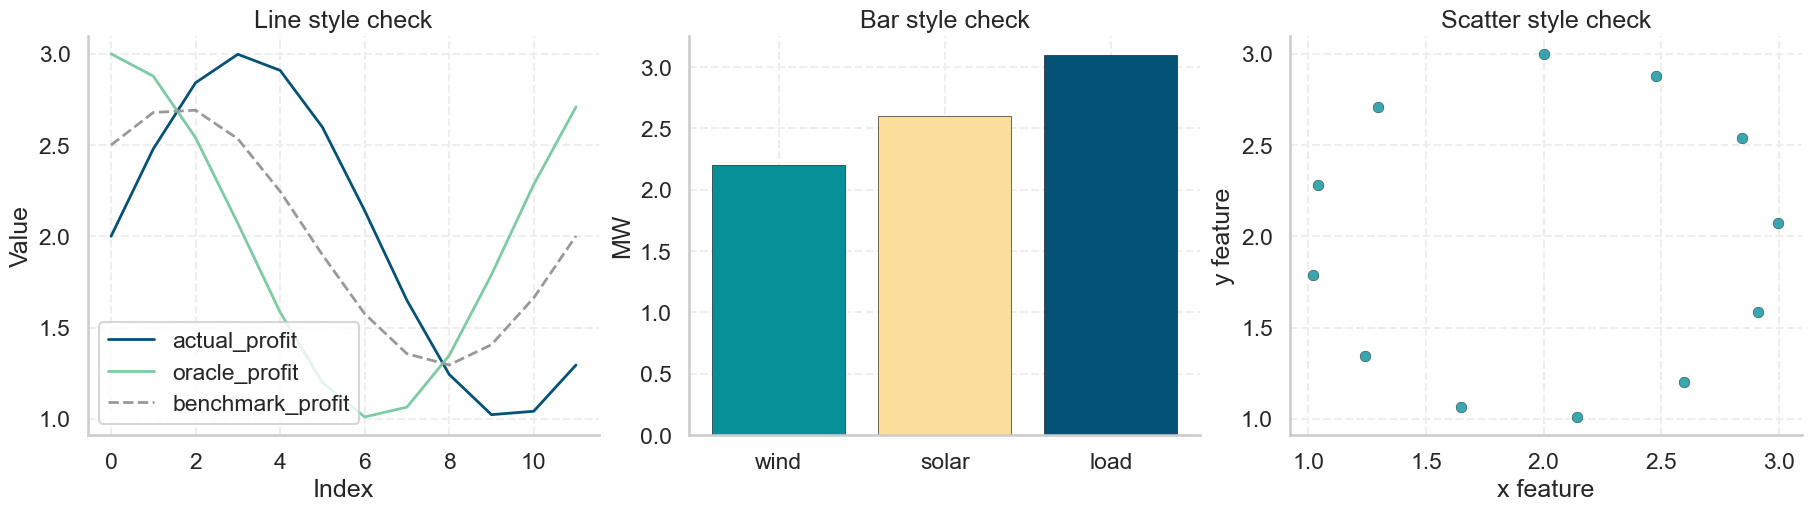

In [2]:
print('figure.figsize:', plt.rcParams['figure.figsize'])
print('axes.grid:', plt.rcParams['axes.grid'])
print('grid.color:', plt.rcParams['grid.color'])
print('grid.linestyle:', plt.rcParams['grid.linestyle'])
print('axes.spines.top:', plt.rcParams['axes.spines.top'])
print('axes.spines.right:', plt.rcParams['axes.spines.right'])

x = np.arange(12)
y1 = np.sin(x / 2) + 2
y2 = np.cos(x / 2) + 2

y_bar = np.array([2.2, 2.6, 3.1])
bar_labels = ['wind', 'solar', 'load']
bar_colors = [ROLE_COLORS['wind'], ROLE_COLORS['solar'], ROLE_COLORS['load']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Line chart
a = axes[0]
a.plot(x, y1, color=ROLE_COLORS['actual_profit'], linewidth=2, label='actual_profit')
a.plot(x, y2, color=ROLE_COLORS['oracle_profit'], linewidth=2, label='oracle_profit')
a.plot(x, (y1 + y2)/2, color=ROLE_COLORS['benchmark_profit'], linewidth=2, linestyle='--', label='benchmark_profit')
a.set_title('Line style check')
a.set_xlabel('Index')
a.set_ylabel('Value')
a.legend()

# Bar chart
a = axes[1]
a.bar(bar_labels, y_bar, color=bar_colors, edgecolor='black', linewidth=0.4)
a.set_title('Bar style check')
a.set_ylabel('MW')

# Scatter chart
a = axes[2]
a.scatter(y1, y2, c=GEO_DIVERGING['div_2'], s=60, alpha=0.8, edgecolor='black', linewidth=0.3)
a.set_title('Scatter style check')
a.set_xlabel('x feature')
a.set_ylabel('y feature')

plt.show()

## 2) Load Project Data (Optional)

Load cleaned data for realistic style previews.

In [3]:
DATA_PATH = Path('data/processed/all_data_clean.parquet')
if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
    df = df.sort_values('timestamp_utc')
    print('Loaded:', DATA_PATH, 'rows=', len(df))
else:
    df = None
    print('Data file not found. Using synthetic examples only.')

Data file not found. Using synthetic examples only.


## Atlernative Color Palettes

Use these only as alternatives if a specific figure needs a different visual encoding.

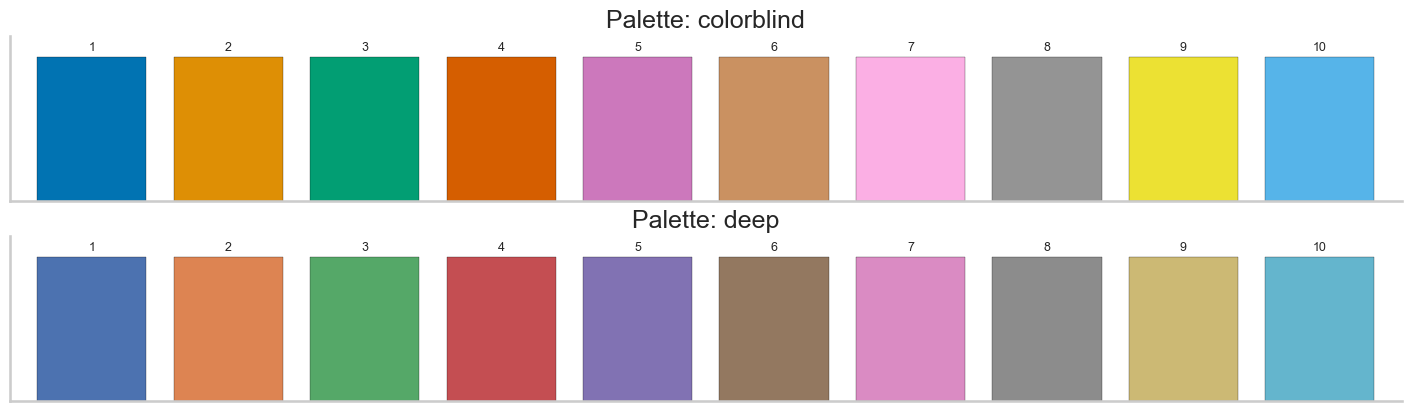

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 4), constrained_layout=True)
for ax, pal_name in zip(axes, ['colorblind', 'deep']):
    palette = sns.color_palette(pal_name, n_colors=10)
    for i, c in enumerate(palette):
        ax.bar(i, 1, color=c, edgecolor='black', linewidth=0.2)
        ax.text(i, 1.03, str(i+1), ha='center', va='bottom', fontsize=9)
    ax.set_xlim(-0.6, 9.6)
    ax.set_ylim(0, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Palette: {pal_name}')
plt.show()

### Alternative: Sequential and Diverging Colormaps

Suggested options:
- Sequential: `viridis`, `cividis`
- Diverging: `coolwarm`, `RdBu_r`

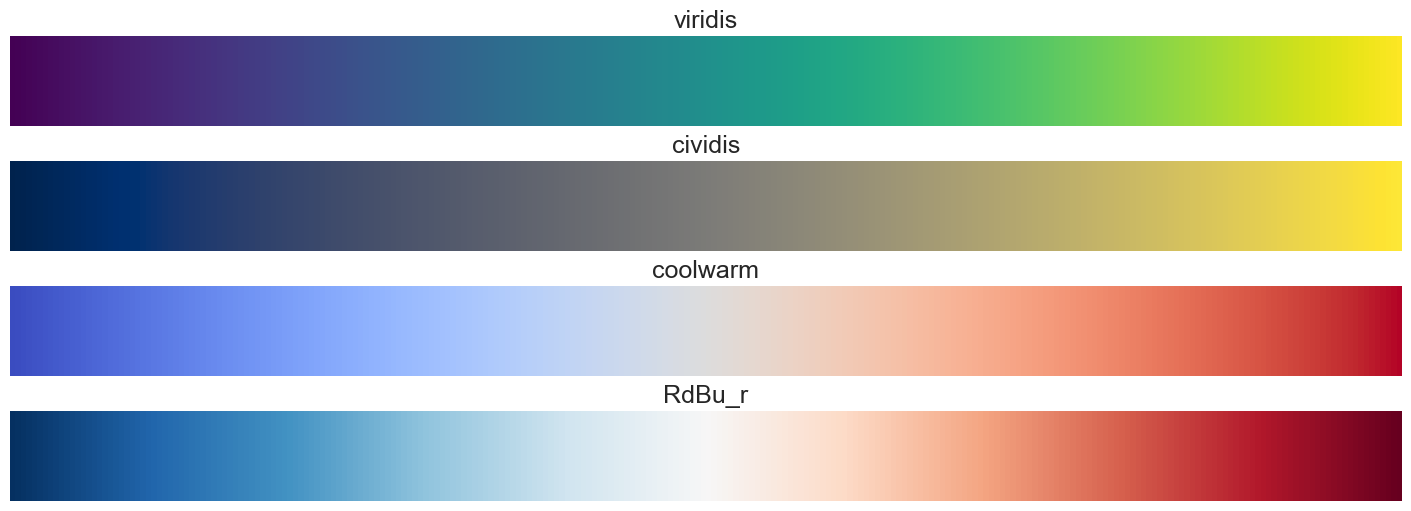

In [5]:
def draw_gradient(ax, cmap_name):
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(grad, aspect='auto', cmap=cmap_name)
    ax.set_title(cmap_name)
    ax.set_axis_off()

fig, axes = plt.subplots(4, 1, figsize=(14, 5), constrained_layout=True)
for ax, cmap in zip(axes, ['viridis', 'cividis', 'coolwarm', 'RdBu_r']):
    draw_gradient(ax, cmap)
plt.show()

### Alternative: Fixed Regime/Event Palette

A fixed palette for regime/event comparisons when you want stable category semantics across multiple figures.

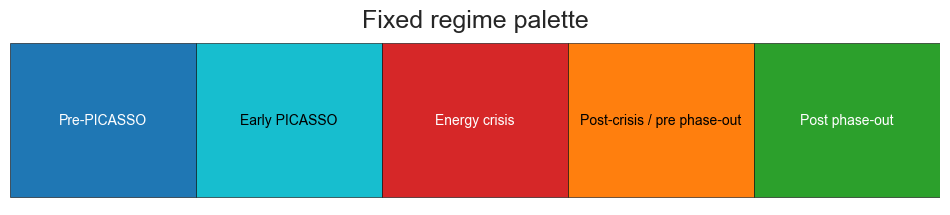

In [6]:
REGIME_COLORS = {
    'Pre-PICASSO': '#1f77b4',            # blue
    'Early PICASSO': '#17becf',          # cyan
    'Energy crisis': '#d62728',          # red
    'Post-crisis / pre phase-out': '#ff7f0e',
    'Post phase-out': '#2ca02c',         # green
}

fig, ax = plt.subplots(figsize=(12, 2.2))
for i, (k, v) in enumerate(REGIME_COLORS.items()):
    ax.barh(0, 1, left=i, color=v, edgecolor='black', linewidth=0.4)
    ax.text(i + 0.5, 0, k, ha='center', va='center', fontsize=10, color='white' if i in [0,2,4] else 'black')
ax.set_xlim(0, len(REGIME_COLORS))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Fixed regime palette')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

## 3) Real-Data Preview

Preview how the style behaves on project-relevant aFRR time series.

In [7]:
if df is None:
    print('No real data available for preview.')
else:
    needed = ['timestamp_utc', 'afrr_avg_activation_price_pos', 'afrr_avg_activation_price_neg']
    if all(c in df.columns for c in needed):
        w = df[['timestamp_utc', 'afrr_avg_activation_price_pos', 'afrr_avg_activation_price_neg']].dropna().tail(24*21)

        # colorblind
        fig, ax = plt.subplots(figsize=(14, 4))
        pal = sns.color_palette('colorblind', 2)
        ax.plot(w['timestamp_utc'], w['afrr_avg_activation_price_pos'], color=pal[0], label='POS')
        ax.plot(w['timestamp_utc'], w['afrr_avg_activation_price_neg'], color=pal[1], label='NEG')
        ax.set_title('Time series preview (palette=colorblind)')
        ax.set_xlabel('Time (UTC)')
        ax.set_ylabel('Activation price [EUR/MWh]')
        ax.legend()
        plt.tight_layout(); plt.show()

        # deep
        fig, ax = plt.subplots(figsize=(14, 4))
        pal = sns.color_palette('deep', 2)
        ax.plot(w['timestamp_utc'], w['afrr_avg_activation_price_pos'], color=pal[0], label='POS')
        ax.plot(w['timestamp_utc'], w['afrr_avg_activation_price_neg'], color=pal[1], label='NEG')
        ax.set_title('Time series preview (palette=deep)')
        ax.set_xlabel('Time (UTC)')
        ax.set_ylabel('Activation price [EUR/MWh]')
        ax.legend()
        plt.tight_layout(); plt.show()
    else:
        print('Required columns not found for real-data preview.')

No real data available for preview.


## 4) Recommended Default

Recommended default setup for thesis figures:
- Primary: GeoDataViz style + `ROLE_COLORS`
- Alternative categorical: `colorblind` / `deep`
- Alternative sequential: `viridis`
- Alternative diverging: `RdBu_r`

## 5) Style Gallery Across Chart Types

Same style semantics applied to multiple chart families (line, bar, violin, scatter, heatmap, area).

In [8]:
if df is None:
    print('No real data available for style gallery.')
else:
    required = [
        'timestamp_utc',
        'afrr_avg_activation_price_pos',
        'afrr_avg_activation_price_neg',
        'wind_onshore_actual',
        'wind_offshore_actual',
        'solar_actual',
        'residual_load_actual',
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print('Missing columns for style gallery:', missing)
    else:
        d = df[required].dropna().copy()
        d['timestamp_utc'] = pd.to_datetime(d['timestamp_utc'], utc=True)
        d = d.sort_values('timestamp_utc')

        # Build helper features for chart demos
        d['renewables_actual'] = d['wind_onshore_actual'] + d['wind_offshore_actual'] + d['solar_actual']
        d['month'] = d['timestamp_utc'].dt.to_period('M').astype(str)
        d['price_spread'] = d['afrr_avg_activation_price_pos'] - d['afrr_avg_activation_price_neg']

        # Keep size manageable
        last = d.tail(24 * 21)  # 3 weeks for line/scatter

        fig, axes = plt.subplots(3, 2, figsize=(16, 14), constrained_layout=True)

        # 1) Line chart
        axes[0, 0].plot(last['timestamp_utc'], last['afrr_avg_activation_price_pos'], color=ROLE_COLORS['actual_profit'], label='POS price')
        axes[0, 0].plot(last['timestamp_utc'], last['afrr_avg_activation_price_neg'], color=GEO_DIVERGING['div_6'], label='NEG price')
        axes[0, 0].set_title('Line chart: aFRR activation prices')
        axes[0, 0].set_xlabel('Time (UTC)')
        axes[0, 0].set_ylabel('EUR/MWh')
        axes[0, 0].legend()

        # 2) Grouped bar chart (monthly means)
        m = d.groupby('month', as_index=False)[['afrr_avg_activation_price_pos', 'afrr_avg_activation_price_neg']].mean().tail(10)
        x = np.arange(len(m))
        w = 0.4
        axes[0, 1].bar(x - w/2, m['afrr_avg_activation_price_pos'], width=w, color=ROLE_COLORS['actual_profit'], label='POS mean')
        axes[0, 1].bar(x + w/2, m['afrr_avg_activation_price_neg'], width=w, color=GEO_DIVERGING['div_6'], label='NEG mean')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(m['month'], rotation=35, ha='right')
        axes[0, 1].set_title('Grouped bar: monthly mean prices (last 10 months)')
        axes[0, 1].set_ylabel('EUR/MWh')
        axes[0, 1].legend()

        # 3) Violin plot (distribution)
        sample = d.tail(24 * 60)
        vv = pd.DataFrame({
            'value': pd.concat([
                sample['afrr_avg_activation_price_pos'],
                sample['afrr_avg_activation_price_neg']
            ], axis=0).values,
            'side': ['POS'] * len(sample) + ['NEG'] * len(sample)
        })
        sns.violinplot(data=vv, x='side', y='value', palette={'POS': ROLE_COLORS['actual_profit'], 'NEG': GEO_DIVERGING['div_6']}, ax=axes[1, 0])
        axes[1, 0].set_title('Violin: price distribution (last 60 days)')
        axes[1, 0].set_ylabel('EUR/MWh')

        # 4) Scatter plot
        sc = last.sample(min(3000, len(last)), random_state=42)
        sns.scatterplot(
            data=sc,
            x='residual_load_actual',
            y='afrr_avg_activation_price_pos',
            color=ROLE_COLORS['load'],
            alpha=0.35,
            s=20,
            ax=axes[1, 1],
        )
        axes[1, 1].set_title('Scatter: residual load vs POS activation price')
        axes[1, 1].set_xlabel('MW')
        axes[1, 1].set_ylabel('EUR/MWh')

        # 5) Heatmap (correlation)
        corr_cols = [
            'afrr_avg_activation_price_pos',
            'afrr_avg_activation_price_neg',
            'wind_onshore_actual',
            'wind_offshore_actual',
            'solar_actual',
            'residual_load_actual',
            'renewables_actual',
            'price_spread',
        ]
        cmat = d[corr_cols].corr()
        sns.heatmap(cmat, cmap='RdBu_r', center=0, annot=False, linewidths=0.3, ax=axes[2, 0])
        axes[2, 0].set_title('Heatmap: feature correlation matrix')

        # 6) Sequential color demo with area chart
        small = d.tail(24 * 14).copy()
        colors = [GEO_SEQUENTIAL_BLUE[f'seq_{i}'] for i in range(2, 7)]
        axes[2, 1].stackplot(
            small['timestamp_utc'],
            small['solar_actual'],
            small['wind_offshore_actual'],
            small['wind_onshore_actual'],
            labels=['Solar', 'Wind offshore', 'Wind onshore'],
            colors=[ROLE_COLORS['solar'], colors[2], ROLE_COLORS['wind']],
            alpha=0.9,
        )
        axes[2, 1].set_title('Area chart: renewable composition (actual)')
        axes[2, 1].set_xlabel('Time (UTC)')
        axes[2, 1].set_ylabel('MW')
        axes[2, 1].legend(loc='upper left')

        plt.show()

No real data available for style gallery.
